In [1]:
import sys
import os
import importlib

parent = os.path.dirname(os.getcwd())
sys.path.insert(0, parent)

from Helpers import loadData, multiplot, sphereMask, saveData, chunker, unchunker, kernelPad
importlib.reload(sys.modules['Helpers.chunker'])
importlib.reload(sys.modules['Helpers.unchunker'])
importlib.reload(sys.modules['Helpers.kernelPad'])
importlib.reload(sys.modules['Helpers'])

import h5py
import matplotlib.pyplot as plt
import numpy as np
import stackview
from scipy.ndimage import zoom

In [3]:
path = r'C:\Users\Lab User\Desktop\ModernExperiments\exp_197\Scan_7.hdf5'
with h5py.File(path,"r") as f:
    print(list(f['RawData'].keys()))
    data = f['RawData']['Scan_7'][()]
    sz = data.shape
    print(sz)

['Scan_7']
(1000, 1216, 1024)


In [4]:
mag = 0.25

zData = np.zeros(shape=(int(sz[0]),int(sz[1]*mag),int(sz[2]*mag)))
for i in range(sz[0]):
    img = zoom(data[i,:,:],mag)
    zData[i,:,:] = img

print(np.shape(zData))

(1000, 304, 256)


In [5]:
fzData = zoom(data,mag)

In [34]:
stackview.slice(zData)

In [6]:
stackview.orthogonal(fzData, continuous_update=True)

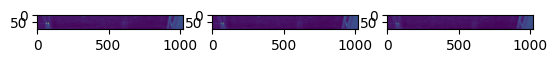

In [44]:
p=200
fig,axs = plt.subplots(1,3)
axs[0].imshow(data[:,p,:])
axs[1].imshow(data[:,p+1,:])
axs[2].imshow(data[:,p+2,:])

In [ ]:
edge_positions = np.argmax(data[:, :, :].max(axis=1), axis=1)
plt.plot(edge_positions)
plt.xlabel('Frame (Z)')
plt.ylabel('X position of bright edge')

In [ ]:
from skimage.registration import phase_cross_correlation

# Align each frame to the first frame
reference = data[0]
aligned = np.zeros_like(data)
aligned[0] = reference

for i in range(1, data.shape[0]):
    shift, _, _ = phase_cross_correlation(reference, data[i])
    aligned[i] = np.roll(data[i], shift.astype(int), axis=(0,1))